**Overview**  
This notebook describes the following steps:
1. Model for regression task is made. Importance of descriptors is assesed.
2. Calculator is made to solve tha main task


In [12]:
import numpy as np
import pandas as pd
from rdkit import RDConfig
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from molfeat.calc import RDKitDescriptors2D, RDKitDescriptors3D
from molfeat.trans import MoleculeTransformer
import datamol as dm
from rdkit.Chem import AllChem

from functools import partial
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, LeaveOneOut


from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, roc_curve
from sklearn.ensemble import RandomForestRegressor

First, we load set of descriptors, target sets and features to drop (we found them during initial descriptors calculation in the very first notebook)

In [14]:
with open('X_standard.pickle', 'rb') as inp:
    X_standard = pickle.load(inp)

In [22]:
with open('viscosity.pickle', 'rb') as inp:
    target = pickle.load(inp)

target = np.log10(target)

**Regression**

The base of the model is RandomForestRegressor, which uses pre-selected features by VariacneTreshgol. Parameters of RandomForesRegressor were found earlier.   
We initialize the model and train it with X_standard dataset

In [18]:
trained_model_reg = Pipeline([('varsel', VarianceThreshold(threshold=0.379)),('randomforest', RandomForestRegressor(max_depth=11,
                                                                                         max_features=None,
                                                                                        criterion='squared_error',
                                                                                         min_samples_leaf=7,
                                                                                         min_samples_split=5,
                                                                                         n_estimators = 22,
                                                                                         n_jobs = -1))])

In [24]:
trained_model_reg.fit(X_standard, target)

Pipeline(steps=[('varsel', VarianceThreshold(threshold=0.379)),
                ('randomforest',
                 RandomForestRegressor(max_depth=11, max_features=None,
                                       min_samples_leaf=7, min_samples_split=5,
                                       n_estimators=22, n_jobs=-1))])

Let's save the model

In [26]:
with open('trained_model_reg.pickle', 'wb') as output:
    pickle.dump(trained_model_reg, output)

And draw feature importances

<BarContainer object of 15 artists>

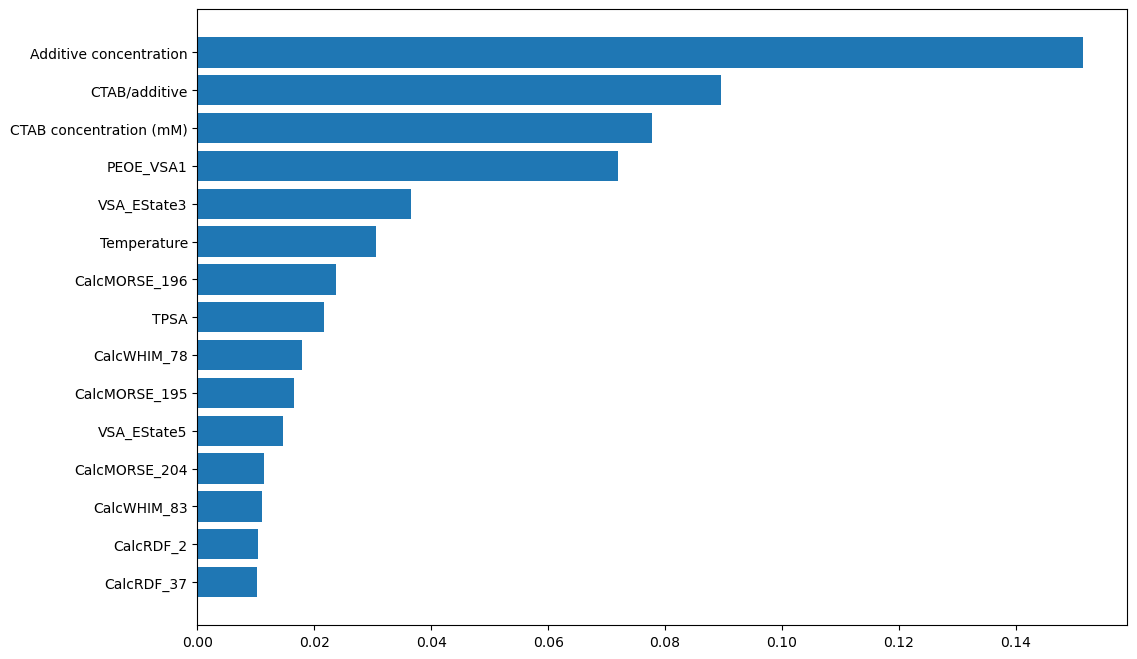

In [33]:
fig = plt.figure(figsize = (12,8))
reg = trained_model_reg.steps[1][1]
feature_selector = trained_model_reg.steps[0][1]
plt.barh(width = reg.feature_importances_[np.argsort(reg.feature_importances_)[-15:]], 
         y = feature_selector.get_feature_names_out()[np.argsort(reg.feature_importances_)[-15:]])

The most important fatures are system features: CTAB concentration, Additive concnetration and CTAB/additive concnetrations ratio. It's important to note, that mpst important chemical descriptors describe 3D features of addditive


**Сalculator**

Here you should hust follow what is written in input strings! Don't forget to activate embed_optmize function

In [50]:
def embed_optimize(smi):
    m = Chem.MolFromSmiles(smi)
    m = Chem.AddHs(m)
    AllChem.EmbedMolecule(m)
    AllChem.MMFFOptimizeMolecule(m, maxIters=500)
    return m

In [40]:
with open('trained_model_reg.pickle', 'rb') as inp:
    trained_model_reg = pickle.load(inp)

with open('X_standard.pickle', 'rb') as inp:
    X_standard = pickle.load(inp)

In [69]:
CTAB_conc = int(input('Enter CTAB Concnetration in mM '))

Enter CTAB Concnetration in mM  75


In [44]:
additive_conentrations = input('Enter additive concentraions in mM like 50,80,60,90 ')
additive_conentrations = [int(x) for x in additive_conentrations.split(',')]

Enter additive concentraions in mM like 50,80,60,90  10,20,30,40,50,60


In [46]:
temp = int(input('Enter the temperature in Celcius degrees '))

Enter the temperature in Celcius degrees  25


In [52]:
SMILES = input('Enter the SMILES of the additive ')
add = embed_optimize(SMILES)

Enter the SMILES of the additive  C(C(C(=O)O)O)C(=O)[O-] 


Here is the function to create dataframe for models. The steps are the same, as in "*1.Hydrotropes.ipynb*" notebook

In [71]:
#fingerprints calculation
fp = AllChem.GetMorganFingerprintAsBitVect(add, radius = 3)
fp_df = pd.DataFrame(np.array(fp).reshape(1,-1), columns = ['fp{}'.format(i) for i in range(2048)])
#descriptors calculation
calc_2D = RDKitDescriptors2D()
calc_3D = RDKitDescriptors3D()
with dm.without_rdkit_log():
    feats_2D = calc_2D(add)
    feats_3D = calc_3D(add)
#create one big features df
features = pd.DataFrame(np.concatenate([feats_2D, feats_3D]).reshape(1,-1), columns=calc_2D.columns + calc_3D.columns)
features = pd.concat([fp_df, features], axis = 1)
#create the df with characteritics of the system (concentration and temperature)
dic = {'CTAB concentration (mM)':[], 'Additive concentration':[], 'CTAB/additive':[], 'Temperature':[] }
for conc in additive_conentrations:
    dic['CTAB concentration (mM)'].append(CTAB_conc)
    dic['Additive concentration'].append(conc)
    dic['CTAB/additive'].append(CTAB_conc/conc)
    dic['Temperature'].append(temp)
df = pd.DataFrame(dic)
#create X_dataframe with several instances - different concentrations of the same additive
X = pd.concat([df, pd.concat([features]*len(additive_conentrations), ignore_index= True)], axis = 1)
#drop unneseccary features
X.drop(columns=['Alerts', 'AvgIpc', 'SPS'], inplace=True)
#X = X.drop(columns = features_to_drop)
X = X[X_standard.columns]

[16:41:21] DEPRECATION WARNING: please use MorganGenerator


Here you should just activate two cells and get the result. 1 is gel, 0 is non-gel, viscosity is given in cP

In [73]:
viscosities = trained_model_reg.predict(X)
print(10**viscosities)


[1.79698933 2.2467829  2.74497265 3.78461805 4.1316839  4.52398366]
